<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_94839/4061945694.py:67: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)
/tmp/ipykernel_94839/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_94839/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_94839/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_94839/4061945694.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_esti

Fitted parameters: alpha = 1.000000, beta = 1.000000
Fitted parameters: alpha = 0.979604, beta = 1.000000
Fitted parameters: alpha = 0.958976, beta = 1.000000
Fitted parameters: alpha = 0.937759, beta = 1.000000
Fitted parameters: alpha = 0.915997, beta = 1.000000
Fitted parameters: alpha = 0.893522, beta = 1.000000


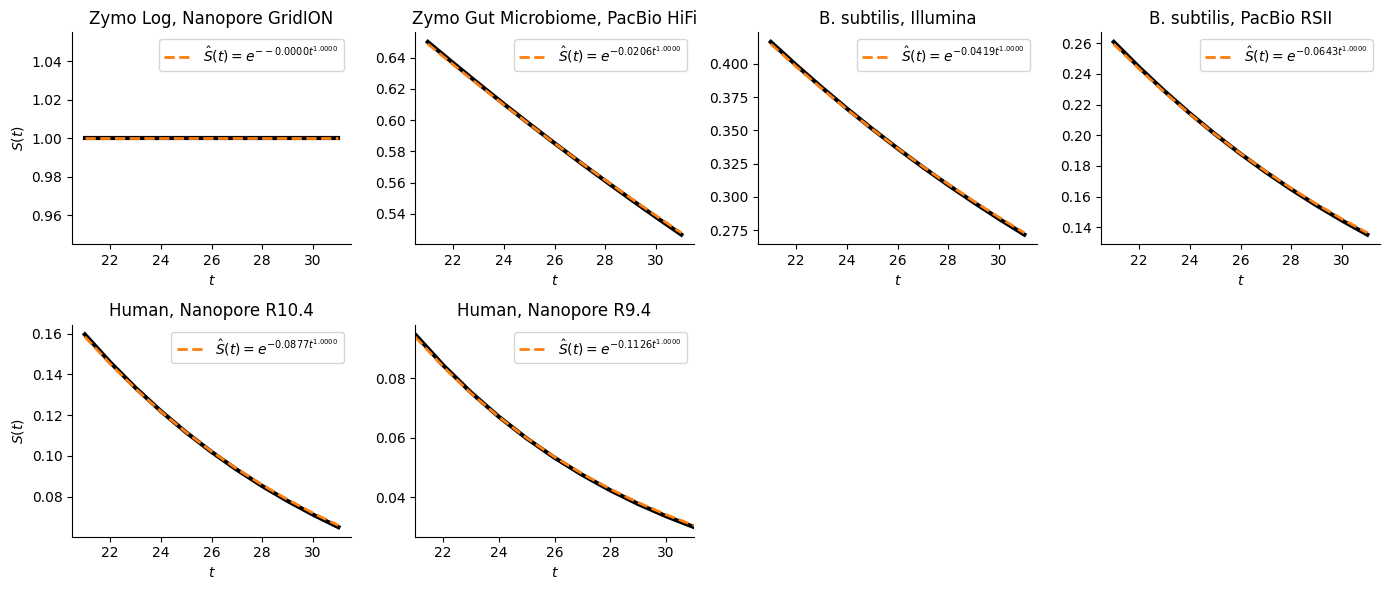

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** ((i) ** 1)


kmer_hit_rate_csv = [
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_100.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_98.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_96.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_94.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_92.matched_kmers.csv",
    "../../output/coverage_dependence_map/Ecoli_K12_MG1655_depth_128_id_90.matched_kmers.csv",
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio HiFi"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(21, 32)
hazard_ratio_estimate_range = range(21, 32)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

ground_truth_lambda = []

func = fit_function_discrete_weibull
#func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = -np.log(alpha)
    ground_truth_lambda.append(l)

    math_label = '$\hat{S}(t) = e^{-%.4ft^{%.4f}}$' % (l, bet)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

In [4]:
ground_truth_lambda

[-0.0,
 0.020607297031180045,
 0.04188948615425529,
 0.06426213669585297,
 0.08774189948193158,
 0.11258444908927909]

In [26]:
import pandas as pd
import glob

output_dir="../../output/coverage_dependence"
prefix = "Ecoli_K12_MG1655"

id = [100, 98, 96, 94, 92, 90]
cov = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Initialize list to store results as a df
identity = []
coverage = []
lambda_estimates = []
beta_estimates = []
coverage_estimates = []
with_reference = []

for i in id:
    for c in cov:
        a_list = []
        b_list = []
        coverage_list = []
        
        output_file_name = f"{output_dir}/{prefix}_depth_{c}_id_{i}_exp_[0-9+].csv"
        output_file_ref_name = f"{output_dir}/{prefix}_depth_{c}_id_{i}_exp_[0-9+]_ref.csv"
        all_files = glob.glob(output_file_name)
        for file in all_files:
            df = pd.read_csv(file)


            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            coverage_estimates.append(df['true_median_coverage'].item())
            identity.append(i)
            coverage.append(c)
            with_reference.append('Without reference')
        
        all_files_ref = glob.glob(output_file_ref_name)
        for file in all_files_ref:
            df = pd.read_csv(file)

            lambda_estimates.append(df['lambda'].item())
            beta_estimates.append(df['beta'].item())
            coverage_estimates.append(df['true_median_coverage'].item())
            identity.append(i)
            coverage.append(c)
            with_reference.append('With reference')


In [27]:
result_df = pd.DataFrame({
    'identity': identity,
    'coverage': coverage,
    'lambda_estimate': lambda_estimates,
    'beta_estimate': beta_estimates,
    'coverage_estimate': coverage_estimates,
    'with_reference': with_reference
})

result_df['error_estimate'] = 1 - np.exp(-result_df['lambda_estimate'])

# Coverage at 100x

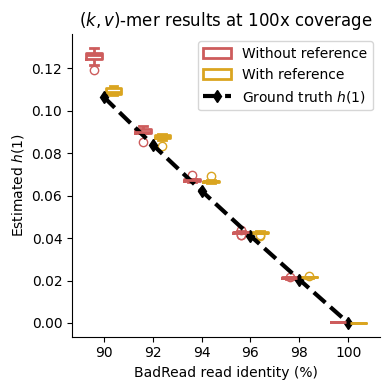

In [28]:
import seaborn as sns

result_df_100x = result_df[result_df['coverage'] == 100]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(4, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
sns.boxplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    fill=False, gap=.2,
    linewidth=2,
    flierprops={"marker": "o"},
    palette=["indianred", "goldenrod"],
)
plt.xlabel("BadRead read identity (%)")
plt.ylabel("Estimated $h(1)$")
plt.title("$(k,v)$-mer results at 100x coverage")
plt.tight_layout()
# Plot ground truth as a lineplot
ground_truth_error = [1 - np.exp(-l) for l in ground_truth_lambda[::-1]]
plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', linestyle='--', marker='d', linewidth=3, label='Ground truth $h(1)$')
plt.legend()
plt.savefig("../../figures/simulated_data_error_rate.svg")



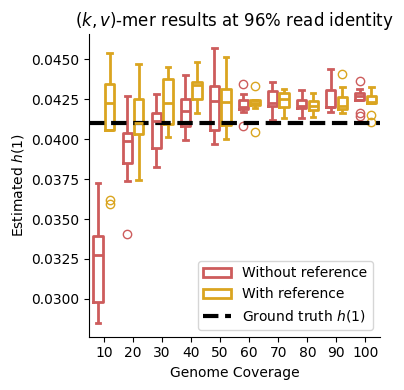

In [29]:
import seaborn as sns

i = 2  # Index for 96% identity


result_df_id = result_df[result_df['identity'] == id[i]]
"""
sns.stripplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=True, alpha=.2, legend=False,
    palette=["indianred", "goldenrod"],
)
sns.pointplot(
    data=result_df_100x, x="identity", y="error_estimate", hue="with_reference",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
    palette=["indianred", "goldenrod"],
)
"""
fig = plt.figure(figsize=(4, 4))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
sns.boxplot(
    data=result_df_id, x="coverage", y="error_estimate", hue="with_reference",
    fill=False, gap=.2,
    linewidth=2,
    flierprops={"marker": "o"},
    palette=["indianred", "goldenrod"],
)
plt.xlabel("Genome Coverage")
plt.ylabel("Estimated $h(1)$")
plt.title("$(k,v)$-mer results at 96% read identity")

# Plot ground truth as a lineplot
ground_truth_error = [1 - np.exp(-l) for l in ground_truth_lambda[::-1]]
#plt.plot(np.arange(len(ground_truth_lambda)), ground_truth_error, color='black', marker='d', linewidth=3, label='Ground truth error rate')
plt.axhline(y=ground_truth_error[::-1][i], color='black', linewidth=3, linestyle='--', label='Ground truth $h(1)$')
plt.legend()
plt.tight_layout()
plt.savefig("../../figures/simulated_data_coverage_dependence.svg")

Read Identity: 100%, Ground Truth Error Rate: 0.0%
Read Identity: 98%, Ground Truth Error Rate: 0.020396417720713655%
Read Identity: 96%, Ground Truth Error Rate: 0.041024245184793195%
Read Identity: 94%, Ground Truth Error Rate: 0.062240853775546556%
Read Identity: 92%, Ground Truth Error Rate: 0.08400273441523376%
Read Identity: 90%, Ground Truth Error Rate: 0.10647811318730838%


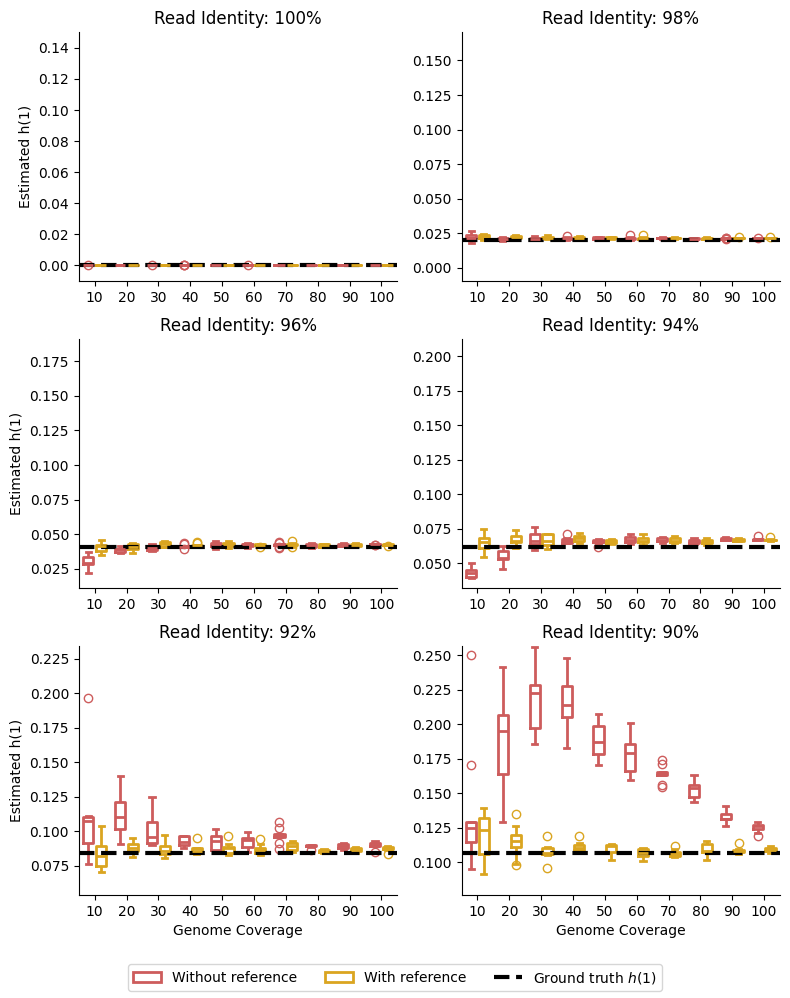

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for idx, identity_value in enumerate(id):
    result_df_subset = result_df[result_df['identity'] == identity_value]
    sns.boxplot(
        data=result_df_subset, x="coverage", y="error_estimate", hue="with_reference",
        fill=False, gap=.2,
        linewidth=2,
        flierprops={"marker": "o"},
        palette=["indianred", "goldenrod"],
        ax=axes[idx]
    )
    gt = ground_truth_error[::-1][idx]
    print(f"Read Identity: {identity_value}%, Ground Truth Error Rate: {gt}%")
    axes[idx].axhline(y=gt, color='black', linewidth=3, linestyle='--', label='Ground truth $h(1)$')
    axes[idx].set_title(f"Read Identity: {identity_value}%")
    if idx >= 4:
        axes[idx].set_xlabel("Genome Coverage")
    else:
        axes[idx].set_xlabel("")
    if idx % 2 == 0:
        axes[idx].set_ylabel("Estimated h(1)")
    else:
        axes[idx].set_ylabel("")
    axes[idx].set_ylim(max(-0.01, gt - 0.03), gt + 0.15)
    axes[idx].get_legend().remove()
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    #axes[idx].set_yscale('log')
    #axes[idx].legend(title="Reference", loc="upper right")
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.1)

# Adjust layout

plt.savefig("../../figures/simulated_data_all_coverage_dependence.pdf")


/tmp/ipykernel_5575/840731883.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


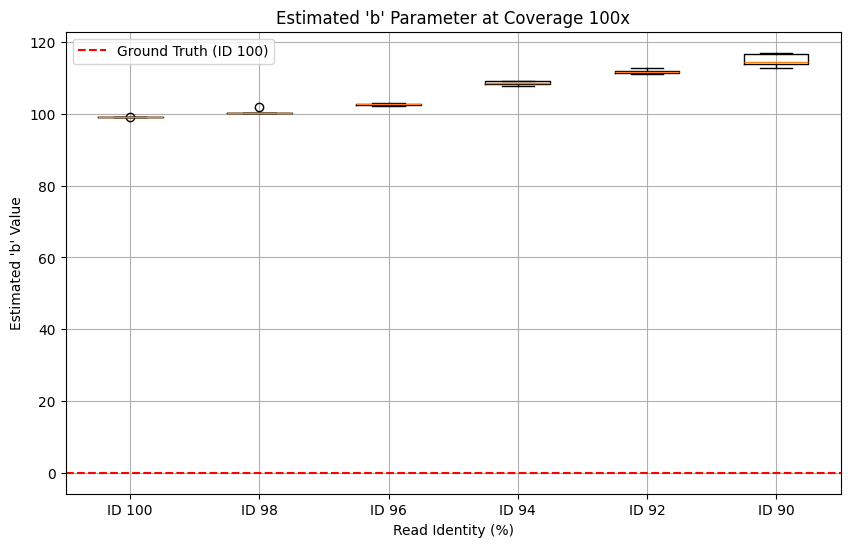

In [21]:
ground_truth_b = [100, 100, 100, 100, 100, 100]

import matplotlib.pyplot as plt
import numpy as np

coverage = 100

# Plot box plot for 'a' parameter
plt.figure(figsize=(10, 6))
data_to_plot = []
labels = []
for i in id:
    key = f"{prefix}_depth_{coverage}_id_{i}"
    data_to_plot.append(results[key]['true_median_coverage'])
    labels.append(f"ID {i}")
plt.boxplot(data_to_plot, labels=labels)
plt.axhline(y=ground_truth_a[id.index(100)], color='r', linestyle='--', label='Ground Truth (ID 100)')
plt.title(f"Estimated 'b' Parameter at Coverage {coverage}x")
plt.xlabel("Read Identity (%)")
plt.ylabel("Estimated 'b' Value")
plt.legend()
plt.grid()
plt.show()
